In [1]:
%pip install pmdarima statsmodels matplotlib pandas numpy scikit-learn seaborn

  Using cached pmdarima-2.1.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (8.5 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cython-3.2.9-cp314-cp314-macosx_11_0_arm64.whl.metadata (4.6 kB)
  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
Using cached pmdarima-2.1.1-cp314-cp314-macosx_11_0_arm64.whl (594 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached cython-3.2.9-cp314-cp314-macosx_11_0_arm64.whl (3.0 MB)
Using cached urllib3-2.7.0-py3-none-any.whl (131 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [pmdarima]2/4 [seaborn]

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import pmdarima as pm

In [3]:
# Dallas/Houston is the only market with real Foursquare crowd-density
# ("heat exposure") coverage -- foursquare_heat_exposure_idw is 0 everywhere
# else in the clean dataset (has_foursquare_data is False for those rows; see
# visitor/clean.py). Using it as a demand exogenous regressor only makes
# sense here.
CLEAN_PATH = Path("data/visitor_daily_store_clean.csv")
if not CLEAN_PATH.exists():
    CLEAN_PATH = Path("../data/visitor_daily_store_clean.csv")

clean = pd.read_csv(CLEAN_PATH, parse_dates=["time_fk"])
dallas_houston = clean[clean["market_fk"] == "Dallas / Houston"]

data = dallas_houston.groupby("time_fk").agg(
    Value=("visitor_count", "sum"),
    heat=("foursquare_heat_exposure_idw", "first"),  # same value for every store in the market that day
).sort_index()
data.index.name = "Date"

data.head()

,Value,heat
Date,,
2020-01-01,5201.0,3906.021429
2020-01-02,11419.0,17718.595238
2020-01-03,15426.0,17859.821429
2020-01-04,9826.0,23155.645671
2020-01-05,6752.0,11840.407143


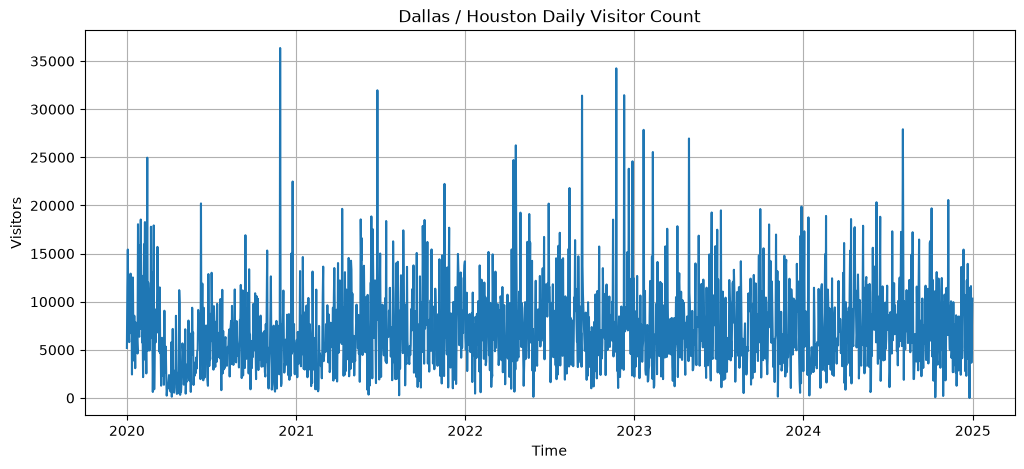

In [4]:
plt.figure(figsize=(12,5))
plt.plot(data.Value)
plt.title("Dallas / Houston Daily Visitor Count")
plt.xlabel("Time")
plt.ylabel("Visitors")
plt.grid(True)
plt.show()

In [5]:
data.Value = data.Value.interpolate()

In [6]:
z = np.abs((data.Value - data.Value.mean()) / data.Value.std())
data["Value_clean"] = np.where(z > 3, data.Value.median(), data.Value)

In [7]:
adf = adfuller(data.Value_clean)
print("ADF Statistic:", adf[0])
print("p-value:", adf[1])

if adf[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is NOT Stationary — Differencing Needed")

ADF Statistic: -7.573724137648574
p-value: 2.797202421397605e-11
Series is Stationary


In [8]:
data["Value_diff"] = data.Value_clean.diff().dropna()

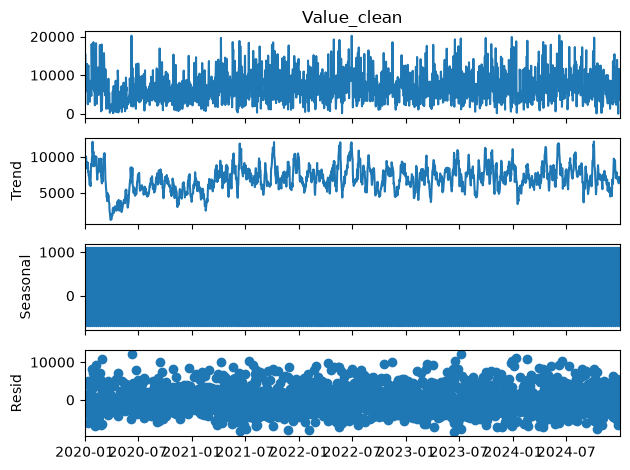

In [9]:
# period=7 (weekly), not 12 -- daily data's dominant seasonal cycle is
# day-of-week, not month-of-year (same choice classical_ts_daily.py makes
# for SARIMAX at this grain).
decomp = seasonal_decompose(data.Value_clean, model="additive", period=7)
decomp.plot()
plt.show()

In [10]:
# Year-based holdout (test = 2024) instead of "last 12" -- matches the
# train/test convention used elsewhere in this project's daily-grain models.
train = data[data.index.year < 2024]
test = data[data.index.year == 2024]

In [11]:
# Foursquare heat exposure (crowd density near the store) correlates ~0.78
# with this market's visitor_count -- passed in as an exogenous regressor
# (X=) instead of forecasting Value_clean blind, univariate.
model = pm.auto_arima(
    train.Value_clean,
    X=train[["heat"]],
    seasonal=True,
    m=7,
    trace=True,
    error_action="ignore",
    suppress_warnings=True
)

model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=27613.317, Time=2.19 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=28544.684, Time=0.08 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=28150.850, Time=0.15 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=27619.283, Time=0.32 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=37721.524, Time=0.01 sec
 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=27612.970, Time=0.57 sec
 ARIMA(2,1,2)(0,0,0)[7] intercept   : AIC=inf, Time=0.56 sec
 ARIMA(2,1,2)(0,0,2)[7] intercept   : AIC=27614.277, Time=1.00 sec
 ARIMA(2,1,2)(1,0,0)[7] intercept   : AIC=27612.978, Time=0.51 sec
 ARIMA(2,1,2)(1,0,2)[7] intercept   : AIC=inf, Time=3.51 sec
 ARIMA(1,1,2)(0,0,1)[7] intercept   : AIC=inf, Time=2.00 sec
 ARIMA(2,1,1)(0,0,1)[7] intercept   : AIC=27622.265, Time=0.56 sec
 ARIMA(3,1,2)(0,0,1)[7] intercept   : AIC=inf, Time=2.15 sec
 ARIMA(2,1,3)(0,0,1)[7] intercept   : AIC=27602.635, Time=2.36 sec
 ARIMA(2,1,3)(0,0,0)[7] intercept   : AIC=2

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1461
Model:               SARIMAX(2, 1, 3)   Log Likelihood              -13792.340
Date:                Tue, 28 Jul 2026   AIC                          27598.679
Time:                        16:41:40   BIC                          27635.682
Sample:                    01-01-2020   HQIC                         27612.483
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
heat           0.3130      0.005     64.430      0.000       0.303       0.323
ar.L1         -1.1530      0.030    -38.533      0.000      -1.212      -1.094
ar.L2         -0.9595      0.028    -34.775      0.000      -1.014      -0.905
ma.L1          0.2109      0.032      6.662      0.000       0.149       0.273
ma.L2         -0.1652      0.029     -5.676      0.000      -0.222      -0.108
ma.L3         -0.9218      0.027    -33.789      0.000      -0.975      -0.868
sigma2      9.936e+06   3.53e-10   2.81e+16      0.000    9.94e+06    9.94e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.24   Jarque-Bera (JB):               452.09
Prob(Q):                              0.63   Prob(JB):                         0.00
Heteroskedasticity (H):               1.41   Skew:                            -0.02
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.73
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.63e+32. Standard errors may be unstable.
"""

In [12]:
# test["heat"] is real historical Foursquare crowd data for 2024, not a
# forecast of it -- a fair backtest only to the extent that reading would be
# available in near-real-time operationally (unlike a weather forecast,
# which has to be predicted days ahead).
forecast = model.predict(n_periods=len(test), X=test[["heat"]])
forecast = pd.Series(forecast, index=test.index)

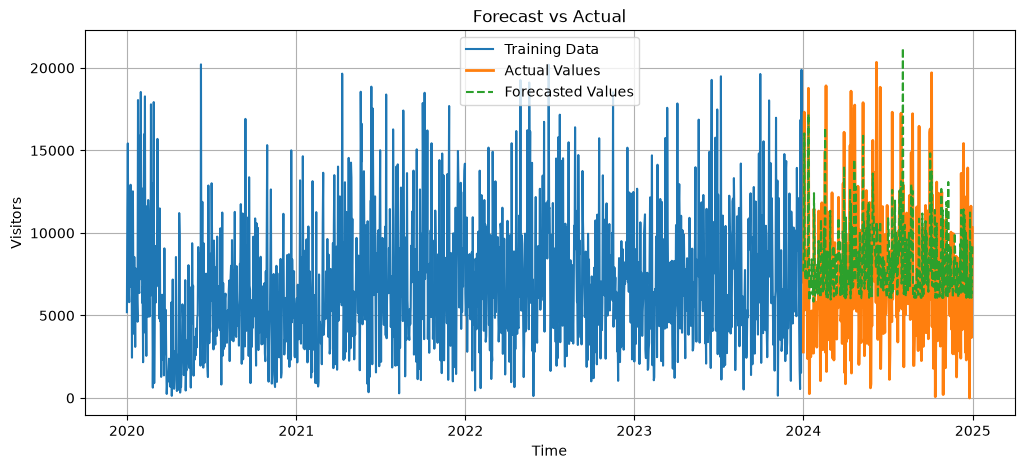

In [13]:
plt.figure(figsize=(12,5))
plt.plot(train.Value_clean, label='Training Data')
plt.plot(test.Value_clean, label='Actual Values', linewidth=2)
plt.plot(forecast, label='Forecasted Values', linestyle="--")
plt.title("Forecast vs Actual")
plt.xlabel("Time")
plt.ylabel("Visitors")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
actual = test.Value_clean
mae = mean_absolute_error(actual, forecast)
mse = mean_squared_error(actual, forecast)
rmse = np.sqrt(mse)
# one day in 2024 has 0 actual visitors -- guard the MAPE division instead of
# letting it divide by zero.
mape = np.nanmean(np.abs((actual - forecast) / actual.replace(0, np.nan))) * 100

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAPE:", mape, "%")

MAE: 2490.1572056065274
MSE: 9300074.826687213
RMSE: 3049.602404689374
MAPE: 90.74307302573874 %


In [ ]:
# Improvement 1: make the weekly pattern explicit instead of relying on
# auto_arima to retain a seasonal ARIMA term. Monday is the reference day;
# dow_1 through dow_6 represent Tuesday through Sunday.
def calendar_exog(frame):
    weekdays = pd.get_dummies(frame.index.dayofweek, prefix="dow", dtype=float)
    weekdays.index = frame.index
    weekdays = weekdays.reindex(
        columns=[f"dow_{day}" for day in range(1, 7)], fill_value=0.0
    )
    return pd.concat([frame[["heat"]].astype(float), weekdays], axis=1)


train_exog = calendar_exog(train)
test_exog = calendar_exog(test)

# Reuse auto_arima's selected ARIMA structure so the only substantive
# change in this comparison is the addition of weekday regressors.
weekday_model = pm.ARIMA(
    order=model.order,
    seasonal_order=model.seasonal_order,
    with_intercept=model.with_intercept,
    suppress_warnings=True,
).fit(train.Value_clean, X=train_exog)

weekday_forecast = pd.Series(
    weekday_model.predict(n_periods=len(test), X=test_exog),
    index=test.index,
    name="weekday_forecast",
)

weekday_comparison = pd.DataFrame(
    {
        "forecast": ["original heat-only", "heat + explicit weekday"],
        "MAE": [
            mean_absolute_error(test.Value_clean, forecast),
            mean_absolute_error(test.Value_clean, weekday_forecast),
        ],
        "minimum_prediction": [forecast.min(), weekday_forecast.min()],
        "prediction_std": [forecast.std(), weekday_forecast.std()],
    }
)
weekday_comparison

In [ ]:
# Improvement 2: rolling one-day-ahead evaluation.
#
# Predict each 2024 day, then append that day's observed count before
# predicting the next day. Parameters stay fixed, so this is fast and avoids
# tuning on the test year; only the model state receives newly available
# observations. This matches an operational next-day forecast, but it is NOT
# a valid month/year-ahead forecast because those future actuals would not yet
# be available.
rolling_result = weekday_model.arima_res_
rolling_values = []

for forecast_date, observed in test.Value_clean.items():
    exog_row = test_exog.loc[[forecast_date]]
    one_step = rolling_result.get_forecast(steps=1, exog=exog_row).predicted_mean
    rolling_values.append(float(np.asarray(one_step).reshape(-1)[0]))
    rolling_result = rolling_result.append(
        endog=pd.Series([observed], index=[forecast_date]),
        exog=exog_row,
        refit=False,
    )

rolling_forecast = pd.Series(
    rolling_values, index=test.index, name="rolling_one_day_forecast"
)

rolling_metrics = pd.DataFrame(
    {
        "forecast": ["one-shot full-year", "rolling one-day-ahead"],
        "MAE": [
            mean_absolute_error(test.Value_clean, weekday_forecast),
            mean_absolute_error(test.Value_clean, rolling_forecast),
        ],
        "minimum_prediction": [weekday_forecast.min(), rolling_forecast.min()],
        "prediction_std": [weekday_forecast.std(), rolling_forecast.std()],
        "days_below_6000": [
            int((weekday_forecast < 6000).sum()),
            int((rolling_forecast < 6000).sum()),
        ],
    }
)

plt.figure(figsize=(12, 5))
plt.plot(test.Value_clean, label="Actual", color="tab:orange", alpha=0.75)
plt.plot(weekday_forecast, label="One-shot ARIMA + weekday", linestyle="--")
plt.plot(rolling_forecast, label="Rolling one-day ARIMA + weekday", linewidth=1.5)
plt.title("One-Shot vs Rolling One-Day-Ahead Forecast")
plt.xlabel("Time")
plt.ylabel("Visitors")
plt.legend()
plt.grid(True)
plt.show()

rolling_metrics

In [ ]:
# Improvement 3: predict a distribution, not only one conditional mean.
# Quantile models estimate P10, P50, and P90 directly. Their lag/rolling
# features use only values from earlier dates. During this 2024 one-day-ahead
# evaluation, that means yesterday's actual is available just as it is in the
# rolling ARIMA evaluation above.
def distribution_features(frame):
    features = calendar_exog(frame)
    for lag in (1, 7, 28):
        features[f"lag_{lag}"] = frame.Value_clean.shift(lag)
    for window in (7, 28):
        features[f"rolling_{window}"] = (
            frame.Value_clean.shift(1).rolling(window).mean()
        )
    return features


all_distribution_features = distribution_features(data)
complete_features = all_distribution_features.notna().all(axis=1)
quantile_X_train = all_distribution_features[
    complete_features & (all_distribution_features.index.year < 2024)
]
quantile_y_train = data.loc[quantile_X_train.index, "Value_clean"]
quantile_X_test = all_distribution_features[all_distribution_features.index.year == 2024]

quantile_predictions = []
quantile_models = {}
for quantile in (0.10, 0.50, 0.90):
    quantile_model = GradientBoostingRegressor(
        loss="quantile",
        alpha=quantile,
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        min_samples_leaf=10,
        random_state=0,
    )
    quantile_model.fit(quantile_X_train, quantile_y_train)
    quantile_models[quantile] = quantile_model
    quantile_predictions.append(quantile_model.predict(quantile_X_test))

# Independently fitted quantiles can occasionally cross. Sorting each row
# guarantees P10 <= P50 <= P90 before the interval is reported.
ordered_quantiles = np.sort(np.column_stack(quantile_predictions), axis=1)
distribution_forecast = pd.DataFrame(
    ordered_quantiles,
    index=quantile_X_test.index,
    columns=["p10", "p50", "p90"],
)

distribution_actual = data.loc[distribution_forecast.index, "Value_clean"]
interval_coverage = (
    (distribution_actual >= distribution_forecast.p10)
    & (distribution_actual <= distribution_forecast.p90)
).mean()

distribution_metrics = pd.DataFrame(
    {
        "metric": ["P50 MAE", "P10-P90 coverage", "P50 minimum", "P10 minimum"],
        "value": [
            mean_absolute_error(distribution_actual, distribution_forecast.p50),
            interval_coverage,
            distribution_forecast.p50.min(),
            distribution_forecast.p10.min(),
        ],
    }
)

plt.figure(figsize=(12, 5))
plt.plot(distribution_actual, label="Actual", color="tab:orange", alpha=0.65)
plt.plot(distribution_forecast.p50, label="P50 forecast", color="tab:green")
plt.fill_between(
    distribution_forecast.index,
    distribution_forecast.p10,
    distribution_forecast.p90,
    color="tab:green",
    alpha=0.2,
    label="P10-P90 forecast interval",
)
plt.title("Rolling One-Day Visitor Distribution Forecast")
plt.xlabel("Time")
plt.ylabel("Visitors")
plt.legend()
plt.grid(True)
plt.show()

distribution_metrics

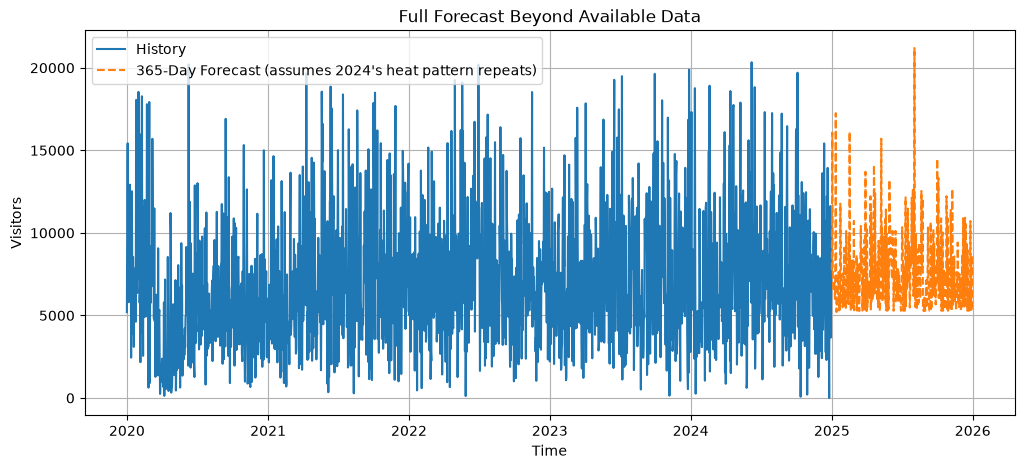

In [15]:
# Beyond-test forecast: refit on the FULL history (train+test), same
# "fit once on everything, then forecast forward" convention predict_future.py
# uses -- fixes a bug in the original template, where this cell re-called
# .predict() on the train-only model (which pmdarima always restarts from the
# end of train, not from wherever the previous predict() call left off) but
# labeled the output with dates starting after the *test* period, silently
# shifting the plotted forecast by len(test) days.
#
# We have no real future Foursquare readings past 2024-12-31, so future
# exog is a seasonal-naive assumption: repeat 2024's actual day-by-day heat
# pattern for the forecast horizon. That's a stated placeholder, not a real
# forecast of crowd density.
HORIZON = 365
future_model = pm.auto_arima(
    data.Value_clean, X=data[["heat"]], seasonal=True, m=7,
    error_action="ignore", suppress_warnings=True,
)

future_index = pd.date_range(data.index[-1] + pd.Timedelta(days=1), periods=HORIZON, freq="D")
future_heat = pd.DataFrame({"heat": data["heat"].iloc[-HORIZON:].to_numpy()}, index=future_index)

future = future_model.predict(n_periods=HORIZON, X=future_heat)
future_series = pd.Series(future, index=future_index)

plt.figure(figsize=(12,5))
plt.plot(data.Value_clean, label="History")
plt.plot(future_series, label=f"{HORIZON}-Day Forecast (assumes 2024's heat pattern repeats)", linestyle="--")
plt.title("Full Forecast Beyond Available Data")
plt.xlabel("Time")
plt.ylabel("Visitors")
plt.legend()
plt.grid(True)
plt.show()